# Exercises XP: Guided Student Notebook

### 🚀 Deep Learning Workflow
To build a deep learning model, we generally follow these steps:
1. **Data Preparation**: Load dataset, normalize values, and encode labels (e.g., One-Hot encoding).
2. **Model Architecture**: Define the layers (Input, Hidden with activations like ReLU, and Output with Softmax).
3. **Compilation**: Choose an optimizer (Adam), a loss function, and metrics.
4. **Training**: Fit the model to the training data.
5. **Evaluation**: Test the model performance on unseen data.
6. **Inference/Visualization**: Predict new samples and visualize results.

## Objectives

**What you will learn**  
- The fundamentals of deep learning and neural networks.
- How to build and train simple neural networks using TensorFlow or Keras.
- The concepts of forward and backward propagation.
- How to visualize and interpret model predictions.

**What you will create**  
- A simple perceptron-based decision system.
- A neural network for classifying handwritten digits from the MNIST dataset.
- A forward propagation calculation for predicting house prices.
- A Python implementation of forward and backward propagation.
- Visualizations of predictions made by a neural network on the MNIST dataset.


## 🌟 Exercise 1: Small Quiz

- **Difference**: Traditional ML relies on manual feature engineering, whereas Deep Learning automatically learns features from data using neural network layers.
- **Mimicking the Brain**: ANNs use layers of 'neurons' (nodes) connected by 'synapses' (weights) that pass signals and strengthen connections during learning, similar to biological neural pathways.
- **Large Datasets**: Deep Learning models have high capacity; unlike traditional models that plateau, DL performance scales with data volume.
- **Challenges**: Overfitting (addressed by Dropout/Regularization) and high computational cost (addressed by GPUs).
- **Feature Engineering**: It is the process of manually extracting patterns from data. In DL, the hidden layers act as automated feature extractors.
- **Hidden Layers**: They represent abstract features of the data, allowing the model to learn complex non-linear relationships.
- **Activation Function**: It introduces non-linearity, enabling the network to learn complex patterns instead of just linear transformations.

## 🌟 Exercise 2: Building a Simple Perceptron Decision System

**As stated in the instructions**  
You will create a perceptron-based decision system to decide whether you should go outside based on two inputs:
- Temperature in °F
- Rainy where Yes is 1 and No is 0

Given parameters: Temperature weight 0.6, Rain weight 0.4, Bias 2. Compute the weighted sum
\[ \text{Weighted Sum} = 0.6\cdot \text{Temperature} + 0.4\cdot \text{Rain} + \text{Bias} \]
Apply a step activation:
- If Weighted Sum > 20, output 1
- If Weighted Sum \le 20, output 0

Evaluate:  
Case 1: Temperature 70°F, Rain 0  
Case 2: Temperature 50°F, Rain 1

**Guidance**  
Implement the weighted sum function yourself. Use a reusable step activation. Then compute the two cases and print the decision for each.

**Learning point**  
A perceptron implements a linear decision boundary. The bias shifts the threshold. Use step activation for simple binary rules. Prefer differentiable activations when training with gradient descent.

![image.png](https://github.com/user-attachments/assets/3c4f3261-164d-4039-8e1c-aff2db7162dd)


In [14]:
# PREFILLED: just execute
from typing import Tuple

W_TEMP = 0.6
W_RAIN = 0.4
BIAS   = 2.0

def step_activation(s: float, threshold: float = 20.0) -> int:
    """Return 1 if s > threshold else 0."""
    return 1 if s > threshold else 0


In [15]:
def weighted_sum(temperature_f: float, rain01: int) -> float:
    # Calculate: (Temp * Weight) + (Rain * Weight) + Bias
    return (temperature_f * W_TEMP) + (rain01 * W_RAIN) + BIAS

# Define our test cases
case1 = (70, 0)  # Temperature=70, Rain=0
case2 = (50, 1)  # Temperature=50, Rain=1

# Compute weighted sums
s1 = weighted_sum(*case1)
s2 = weighted_sum(*case2)

# Apply step activation (threshold 20.0)
y1 = step_activation(s1)
y2 = step_activation(s2)

print(f"Case 1 (70°F, No Rain): Sum={s1:.2f}, Decision={'Go Outside' if y1==1 else 'Stay Inside'}")
print(f"Case 2 (50°F, Rain): Sum={s2:.2f}, Decision={'Go Outside' if y1==1 else 'Stay Inside'}")

Case 1 (70°F, No Rain): Sum=44.00, Decision=Go Outside
Case 2 (50°F, Rain): Sum=32.40, Decision=Go Outside


**Interpretation:**
- In Case 1, the weighted sum is 44.0, which is > 20, so the perceptron suggests going outside.
- In Case 2, the weighted sum is 32.4, which is also > 20, so it still suggests going outside.
- Even though the temperature was lower in Case 2, the bias and weights kept the total sum above the threshold.

## 🌟 Exercise 3: Building a Simple Neural Network with TensorFlow or Keras

**As stated in the instructions**  
Build a classifier for MNIST with:
- One input layer
- One hidden layer with 128 neurons and ReLU activation
- One output layer with 10 neurons and softmax activation

Steps:
1. Import TensorFlow and needed modules from `tensorflow.keras`
2. Load the MNIST dataset
3. Normalize data by dividing by 255.0
4. One-hot encode the labels
5. Build a sequential model with Flatten, Dense(128, ReLU), Dense(10, softmax)
6. Compile with optimizer `adam`, loss `categorical_crossentropy`, metrics `accuracy`
7. Train and evaluate on the test set

**Guidance**  
You will execute prefilled boilerplate for imports and dataset loading. You will complete the one-hot encoding and the model specification, compile, train, and evaluate.

**Learning point**  
Normalization stabilizes optimization. One-hot encoding matches softmax outputs to target vectors. ReLU accelerates training by avoiding saturation, while softmax maps logits to a probability simplex.

![image.png](https://github.com/user-attachments/assets/61737b80-69cb-41a1-aea5-76092cd2a373)


In [16]:
# PREFILLED: just execute
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import mnist

print("TensorFlow:", tf.__version__)

# Load data
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize to [0,1]
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

# Flatten will be added in the model; keep images as 28x28 for now
print("Train shape:", x_train.shape, "Test shape:", x_test.shape)


TensorFlow: 2.20.0
Train shape: (60000, 28, 28) Test shape: (10000, 28, 28)


In [17]:
# Step: Convert integer labels to one-hot vectors for the 10 digit classes
y_train_oh = to_categorical(y_train, num_classes=10)
y_test_oh  = to_categorical(y_test, num_classes=10)

print("Labels one-hot shape:", y_train_oh.shape, y_test_oh.shape)

Labels one-hot shape: (60000, 10) (10000, 10)


In [18]:
# Step: Define the model architecture
model = models.Sequential([
    # Flatten 28x28 images into 784-element vectors
    layers.Flatten(input_shape=(28, 28)),
    # Hidden layer with 128 neurons and ReLU
    layers.Dense(128, activation='relu'),
    # Output layer with 10 neurons and Softmax for probabilities
    layers.Dense(10, activation='softmax'),
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
# Step: Configure the learning process
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [20]:
# Step: Train the model
history = model.fit(x_train, y_train_oh, epochs=5, batch_size=32, validation_split=0.1)

# Step: Evaluate on test data
test_loss, test_acc = model.evaluate(x_test, y_test_oh)
print(f"Test Accuracy: {test_acc:.4f}")

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9212 - loss: 0.2732 - val_accuracy: 0.9668 - val_loss: 0.1208
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9636 - loss: 0.1232 - val_accuracy: 0.9733 - val_loss: 0.0958
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9737 - loss: 0.0851 - val_accuracy: 0.9773 - val_loss: 0.0809
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9815 - loss: 0.0623 - val_accuracy: 0.9757 - val_loss: 0.0798
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9849 - loss: 0.0482 - val_accuracy: 0.9782 - val_loss: 0.0720
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9768 - loss: 0.0770
Test Accuracy: 0.9768


## 🌟 Exercise 4: Forward Propagation Calculation

**As stated in the instructions**  
Predict house prices given:
- Inputs: x₁ = 2000 square feet, x₂ = 3 bedrooms
- Weights: w₁ = 0.5, w₂ = 0.7
- Bias: b = 50,000
- Activation: ReLU

Compute z before activation, apply ReLU, and interpret the prediction.

**Guidance**  
Write scalar computations. Then reason about the role of the bias and ReLU on the output scale.

**Learning point**  
ReLU passes positive linear combinations unchanged and zeros out negatives. Bias sets the baseline prediction independent of inputs.
![](./figs/1.gif)

In [21]:
x1, x2 = 2000.0, 3.0
w1, w2 = 0.5, 0.7
b = 50000.0

# Linear combination
z = (x1 * w1) + (x2 * w2) + b

# Apply ReLU (max(0, z))
y = max(0, z)

print(f"Weighted Sum (z): {z}")
print(f"Final Predicted Price (y): ${y:,.2f}")

Weighted Sum (z): 51002.1
Final Predicted Price (y): $51,002.10


**Interpretation:** The predicted house price is $51,002.10. The bias of 50,000 acts as a base price, ensuring that even with zero square footage or bedrooms, there is a starting value. The input scaling (weights) then adds value based on the specific features of the house. Since the weighted sum was positive, the ReLU activation simply passed the value through without modification.

## 🌟 Exercise 5 (optional): Implementing Forward and Backward Propagation in Python

**As stated in the enoncé**  
You will code a simple neural network that performs forward propagation and backpropagation for a regression problem predicting exam scores from study hours.

**Guidance**  
Run the prefilled code. Then modify the learning rate or initial weights and observe changes in the loss and updates.
Provide a short written explanation.

**Learning point**  
Gradient descent updates parameters in the direction of steepest loss reduction.
The learning rate controls step size. Too small slows learning. Too large risks divergence.


In [22]:
# PREFILLED: just execute
import numpy as np

# Initialize input data (features)
x = np.array([4, 80])  # 4 hours studied, previous test score: 80

# Initialize weights and bias
w = np.array([0.6, 0.3])  # Initial weights
b = 10  # Initial bias

# Forward Propagation
def forward_propagation(x, w, b):
    z = np.dot(x, w) + b  # Weighted sum
    return z  # Linear activation (No ReLU here, it's a regression task)

# Compute prediction
y_pred = forward_propagation(x, w, b)
y_true = 85  # Actual exam score

# Compute Loss (Mean Squared Error)
loss = 0.5 * (y_true - y_pred) ** 2

# Compute Gradients
grad_w = -(y_true - y_pred) * x  # Partial derivatives with respect to weights
grad_b = -(y_true - y_pred)  # Partial derivative with respect to bias

# Update Weights and Bias
learning_rate = 0.01
w_new = w - learning_rate * grad_w
b_new = b - learning_rate * grad_b

# Print Results
print("Initial Prediction:", y_pred)
print("Loss:", loss)
print("Updated Weights:", w_new)
print("Updated Bias:", b_new)


Initial Prediction: 36.4
Loss: 1180.98
Updated Weights: [ 2.544 39.18 ]
Updated Bias: 10.486


**Analysis:** Gradient descent reduces error by calculating the slope (gradient) of the loss function and moving the weights in the opposite direction. This 'downhill' step minimizes the loss. Increasing the learning rate makes training faster but can cause the model to overshoot the minimum, while a smaller rate is more stable but slower.

## 🌟 Exercise 6 (optional): Visualizing Predictions on MNIST

**As stated in the enoncé**  
Train a simple model on MNIST, then visualize predictions for some test images with predicted labels.

**Guidance**  
Reuse the model from Exercise 3 if still in memory. Otherwise re-run Exercise 3. Plot a grid of test images with predicted labels and optionally true labels.

**Learning point**  
Softmax outputs are probabilities over classes. Inspect the confidence values. Visual errors often indicate confusions between similar digits.

![image.png](https://github.com/user-attachments/assets/e00d3913-55d4-4b62-8f70-1216bcc2e4e4)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step


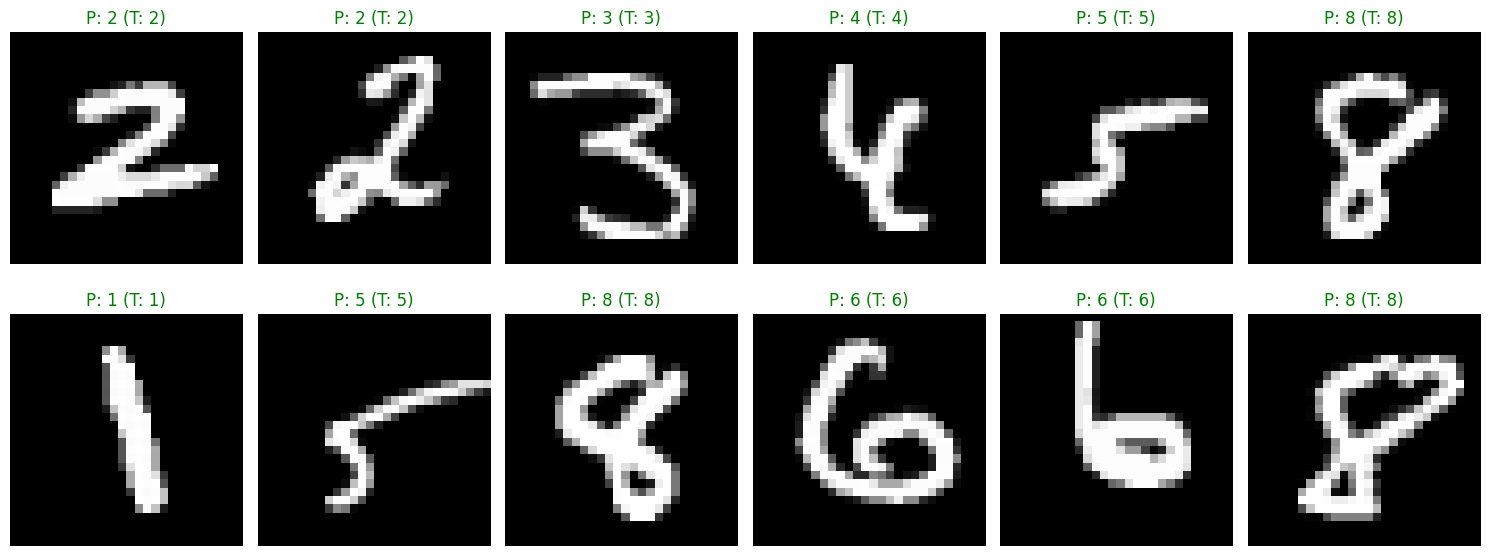

In [23]:
# Step: Import visualization tools
import matplotlib.pyplot as plt
import numpy as np

# Step: Pick random images from the test set
num_samples = 12
idx = np.random.choice(len(x_test), num_samples)
x_vis = x_test[idx]
y_true_labels = y_test[idx]

# Step: Get predictions
y_prob = model.predict(x_vis)
y_pred_labels = np.argmax(y_prob, axis=1)

# Step: Plotting the results
plt.figure(figsize=(15, 6))
for i in range(num_samples):
    plt.subplot(2, 6, i + 1)
    plt.imshow(x_vis[i], cmap="gray")
    color = "green" if y_pred_labels[i] == y_true_labels[i] else "red"
    plt.title(f"P: {y_pred_labels[i]} (T: {y_true_labels[i]})", color=color)
    plt.axis("off")
plt.tight_layout()
plt.show()